In [27]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


In [28]:
RUN_DIR_svd = Path("state_spectrum_sweep/experiments/hf_low_rank_20260415_060329")
RUN_DIR_q = Path("state_spectrum_sweep/experiments/hf_quant_20260412_084456")

assert RUN_DIR_svd.exists(), f"Run directory not found: {RUN_DIR_svd}"
assert RUN_DIR_q.exists(), f"Run directory not found: {RUN_DIR_q}"

RUN_DIR_svd, RUN_DIR_q


(PosixPath('state_spectrum_sweep/experiments/hf_low_rank_20260415_060329'),
 PosixPath('state_spectrum_sweep/experiments/hf_quant_20260412_084456'))

In [29]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def load_tensor(path: Path):
    return torch.load(path, map_location="cpu")

def prompt_ids(run_dir: Path):
    return sorted({p.name.split("_meta.json")[0] for p in run_dir.glob("prompt_*_meta.json")})

def load_prompt_artifacts(run_dir: Path, prompt_id: str):
    meta_path = run_dir / f"{prompt_id}_meta.json"
    text_path = run_dir / f"{prompt_id}_prompt_response.txt"

    artifacts = {
        "prompt_id": prompt_id,
        "meta": load_json(meta_path) if meta_path.exists() else None,
        "response_text": text_path.read_text(encoding="utf-8") if text_path.exists() else None,
    }

    for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
        tensor_path = run_dir / f"{prompt_id}_{metric_name}.pt"
        artifacts[metric_name] = load_tensor(tensor_path) if tensor_path.exists() else None

    return artifacts

def load_run(run_dir: Path):
    ids = prompt_ids(run_dir)
    return [load_prompt_artifacts(run_dir, prompt_id) for prompt_id in ids]

all_prompt_ids_svd = prompt_ids(RUN_DIR_svd)
all_prompt_ids_q = prompt_ids(RUN_DIR_q)

all_prompt_ids_svd, all_prompt_ids_q[:5]


(['prompt_01',
  'prompt_02',
  'prompt_03',
  'prompt_04',
  'prompt_05',
  'prompt_06',
  'prompt_07',
  'prompt_08',
  'prompt_09',
  'prompt_10'],
 ['prompt_01', 'prompt_02', 'prompt_03', 'prompt_04', 'prompt_05'])

In [30]:
all_prompt_ids_q = prompt_ids(RUN_DIR_q)
all_prompt_ids_q

['prompt_01',
 'prompt_02',
 'prompt_03',
 'prompt_04',
 'prompt_05',
 'prompt_06',
 'prompt_07',
 'prompt_08',
 'prompt_09',
 'prompt_10']

In [31]:
records_svd = load_run(RUN_DIR_svd)
records_q = load_run(RUN_DIR_q)

len(records_svd), len(records_q)


(10, 10)

In [32]:
def index_by_prompt(records):
    return {r["prompt_id"]: r for r in records}

records_svd_by_id = index_by_prompt(records_svd)
records_q_by_id = index_by_prompt(records_q)

common_prompt_ids = sorted(set(records_svd_by_id) & set(records_q_by_id))
common_prompt_ids


['prompt_01',
 'prompt_02',
 'prompt_03',
 'prompt_04',
 'prompt_05',
 'prompt_06',
 'prompt_07',
 'prompt_08',
 'prompt_09',
 'prompt_10']

In [33]:
# Quick metadata check
meta_example_svd = records_svd_by_id[common_prompt_ids[0]]["meta"]
meta_example_q = records_q_by_id[common_prompt_ids[0]]["meta"]

meta_example_svd, meta_example_q


({'prompt_len': 7,
  'num_generated_tokens': 64,
  'num_metric_steps': 64,
  'stopped_reason': 'max_new_tokens',
  'prefill_seconds': 0.627468744001817,
  'average_transform_seconds': 0.09455440217129762,
  'num_state_tensors': 48,
  'state_tensor_names': ['layers.0.conv_states',
   'layers.0.recurrent_states',
   'layers.1.conv_states',
   'layers.1.recurrent_states',
   'layers.2.conv_states',
   'layers.2.recurrent_states',
   'layers.3.conv_states',
   'layers.3.recurrent_states',
   'layers.4.conv_states',
   'layers.4.recurrent_states',
   'layers.5.conv_states',
   'layers.5.recurrent_states',
   'layers.6.conv_states',
   'layers.6.recurrent_states',
   'layers.7.conv_states',
   'layers.7.recurrent_states',
   'layers.8.conv_states',
   'layers.8.recurrent_states',
   'layers.9.conv_states',
   'layers.9.recurrent_states',
   'layers.10.conv_states',
   'layers.10.recurrent_states',
   'layers.11.conv_states',
   'layers.11.recurrent_states',
   'layers.12.conv_states',
   'la

In [34]:
def summarize_step_layer_tensor(x: torch.Tensor):
    x = x.float().cpu()
    out = {
        "shape": tuple(x.shape),
        "mean": float(x.mean().item()),
        "std": float(x.std().item()) if x.numel() > 1 else 0.0,
        "min": float(x.min().item()),
        "max": float(x.max().item()),
    }

    if x.ndim >= 2:
        out["mean_over_layers_per_step"] = x.mean(dim=1)
        out["max_over_layers_per_step"] = x.max(dim=1).values
        out["mean_over_steps_per_layer"] = x.mean(dim=0)
        out["max_over_steps_per_layer"] = x.max(dim=0).values
    elif x.ndim == 1:
        out["per_step"] = x
    return out


In [57]:
def run_summary_dataframe(records, label):
    rows = []
    for rec in records:
        meta = rec["meta"] or {}
        row = {
            "run_type": label,
            "prompt_id": rec["prompt_id"],
            "experiment": meta.get("experiment"),
            "subset": meta.get("subset"),
            "prompt_len": meta.get("prompt_len"),
            "num_generated_tokens": meta.get("num_generated_tokens"),
            "num_metric_steps": meta.get("num_metric_steps"),
            "stopped_reason": meta.get("stopped_reason"),
            "prefill_seconds": meta.get("prefill_seconds"),
            "average_transform_seconds": meta.get("average_transform_seconds"),
            "num_state_tensors": meta.get("num_state_tensors"),
        }

        for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
            tensor = rec[metric_name]
            if tensor is None:
                continue
            stats = summarize_step_layer_tensor(tensor)
            row[f"{metric_name}_mean"] = stats["mean"]
            row[f"{metric_name}_std"] = stats["std"]
            row[f"{metric_name}_min"] = stats["min"]
            row[f"{metric_name}_max"] = stats["max"]

            if tensor.ndim == 1:
                row[f"{metric_name}_median"] = float(tensor.float().median().item())
                row[f"{metric_name}_p99"] = float(torch.quantile(tensor.float(), 0.99).item())

        rows.append(row)
    return pd.DataFrame(rows).sort_values(["run_type", "prompt_id"]).reset_index(drop=True)

df_svd = run_summary_dataframe(records_svd, "low_rank")
df_q = run_summary_dataframe(records_q, "quant")
df_all = pd.concat([df_svd, df_q], ignore_index=True)

df_all.head()

,run_type,prompt_id,experiment,subset,prompt_len,num_generated_tokens,num_metric_steps,stopped_reason,prefill_seconds,average_transform_seconds,...,rel_frob_min,rel_frob_max,cosine_similarity_mean,cosine_similarity_std,cosine_similarity_min,cosine_similarity_max,retained_energy_mean,retained_energy_std,retained_energy_min,retained_energy_max
0,low_rank,prompt_01,low_rank,auto,7,64,64,max_new_tokens,0.627468744002,0.094554402171,...,0.0,0.004119873047,1.000055909157,0.004041517153,0.9921875,1.0078125,1.0,0.0,1.0,1.0
1,low_rank,prompt_02,low_rank,auto,8,64,64,max_new_tokens,0.013957817006,0.092525540952,...,0.0,0.003906250000,0.999895751476,0.003967343364,0.9921875,1.0078125,1.0,0.0,1.0,1.0
2,low_rank,prompt_03,low_rank,auto,9,64,64,max_new_tokens,0.014923032999,0.096837988327,...,0.0,0.006103515625,0.999987304211,0.003865954001,0.9921875,1.0078125,1.0,0.0,1.0,1.0
3,low_rank,prompt_04,low_rank,auto,12,64,64,max_new_tokens,0.020004406993,0.096804238702,...,0.0,0.006652832031,0.999895751476,0.003847817890,0.9921875,1.0078125,1.0,0.0,1.0,1.0
4,low_rank,prompt_05,low_rank,auto,14,64,64,max_new_tokens,0.018839992001,0.078126341360,...,0.0,0.006530761719,0.999982178211,0.003854349488,0.9921875,1.0078125,1.0,0.0,1.0,1.0


In [56]:
# Verify whether the retained energy tensor really contains only ones
x = records_svd_by_id["prompt_02"]["retained_energy"]
torch.unique(x)

tensor([1.])

In [36]:
# Join SVD and quant by prompt_id for direct comparison
paired = df_svd.merge(df_q, on="prompt_id", suffixes=("_svd", "_q"))
paired.head()


,run_type_svd,prompt_id,experiment_svd,subset_svd,prompt_len_svd,num_generated_tokens_svd,num_metric_steps_svd,stopped_reason_svd,prefill_seconds_svd,average_transform_seconds_svd,...,rel_frob_min_q,rel_frob_max_q,cosine_similarity_mean_q,cosine_similarity_std_q,cosine_similarity_min_q,cosine_similarity_max_q,retained_energy_mean_q,retained_energy_std_q,retained_energy_min_q,retained_energy_max_q
0,low_rank,prompt_01,low_rank,auto,7,64,64,max_new_tokens,0.627469,0.094554,...,0.009155,0.126953,0.998835,0.003416,0.988281,1.007812,0.998554,0.002900,0.984375,1.0
1,low_rank,prompt_02,low_rank,auto,8,64,64,max_new_tokens,0.013958,0.092526,...,0.009277,0.123535,0.998820,0.003472,0.988281,1.007812,0.998474,0.002926,0.984375,1.0
2,low_rank,prompt_03,low_rank,auto,9,64,64,max_new_tokens,0.014923,0.096838,...,0.009155,0.129883,0.998880,0.003412,0.988281,1.007812,0.998430,0.003004,0.984375,1.0
3,low_rank,prompt_04,low_rank,auto,12,64,64,max_new_tokens,0.020004,0.096804,...,0.009521,0.127930,0.998793,0.003433,0.984375,1.007812,0.998366,0.003003,0.984375,1.0
4,low_rank,prompt_05,low_rank,auto,14,64,64,max_new_tokens,0.018840,0.078126,...,0.008911,0.132812,0.998965,0.003429,0.988281,1.007812,0.998545,0.002877,0.984375,1.0


In [53]:
df_all.columns.tolist()

['run_type',
 'prompt_id',
 'experiment',
 'subset',
 'prompt_len',
 'num_generated_tokens',
 'num_metric_steps',
 'stopped_reason',
 'prefill_seconds',
 'average_transform_seconds',
 'num_state_tensors',
 'kl_mean',
 'kl_std',
 'kl_min',
 'kl_max',
 'kl_median',
 'kl_p99',
 'mse_mean',
 'mse_std',
 'mse_min',
 'mse_max',
 'rel_frob_mean',
 'rel_frob_std',
 'rel_frob_min',
 'rel_frob_max',
 'cosine_similarity_mean',
 'cosine_similarity_std',
 'cosine_similarity_min',
 'cosine_similarity_max',
 'retained_energy_mean',
 'retained_energy_std',
 'retained_energy_min',
 'retained_energy_max']

In [37]:
# 1. Single-prompt deep dive, mirroring the original notebook
PROMPT_ID = common_prompt_ids[1] if len(common_prompt_ids) > 1 else common_prompt_ids[0]

rec_svd = records_svd_by_id[PROMPT_ID]
rec_q = records_q_by_id[PROMPT_ID]

kl_svd = rec_svd["kl"].float().cpu()
mse_svd = rec_svd["mse"].float().cpu()
rf_svd = rec_svd["rel_frob"].float().cpu()
cos_svd = rec_svd["cosine_similarity"].float().cpu()
re_svd = rec_svd["retained_energy"].float().cpu()

kl_q = rec_q["kl"].float().cpu()
mse_q = rec_q["mse"].float().cpu()
rf_q = rec_q["rel_frob"].float().cpu()
cos_q = rec_q["cosine_similarity"].float().cpu()
re_q = rec_q["retained_energy"].float().cpu()

steps_svd = np.arange(len(kl_svd))
steps_q = np.arange(len(kl_q))

log_kl_svd = torch.log1p(kl_svd)
log_kl_q = torch.log1p(kl_q)

rf_mean_svd = rf_svd.mean(dim=1)
rf_max_svd = rf_svd.max(dim=1).values
rf_tail_svd = rf_svd[:, -4:].mean(dim=1)

mse_mean_svd = mse_svd.mean(dim=1)
mse_max_svd = mse_svd.max(dim=1).values

re_mean_svd = re_svd.mean(dim=1)
re_min_svd = re_svd.min(dim=1).values

cos_mean_svd = cos_svd.mean(dim=1)
cos_min_svd = cos_svd.min(dim=1).values

rf_mean_q = rf_q.mean(dim=1)
rf_max_q = rf_q.max(dim=1).values
rf_tail_q = rf_q[:, -4:].mean(dim=1)

mse_mean_q = mse_q.mean(dim=1)
mse_max_q = mse_q.max(dim=1).values

re_mean_q = re_q.mean(dim=1)
re_min_q = re_q.min(dim=1).values

cos_mean_q = cos_q.mean(dim=1)
cos_min_q = cos_q.min(dim=1).values

high_mask_svd = kl_svd >= torch.quantile(kl_svd, 0.9)
high_mask_q = kl_q >= torch.quantile(kl_q, 0.9)

print("PROMPT_ID:", PROMPT_ID)
print("SVD high-KL steps:", torch.where(high_mask_svd)[0].tolist())
print("Q high-KL steps:", torch.where(high_mask_q)[0].tolist())


PROMPT_ID: prompt_02
SVD high-KL steps: [1, 4, 8, 15, 24, 40, 56]
Q high-KL steps: [1, 3, 8, 9, 19, 25, 50]


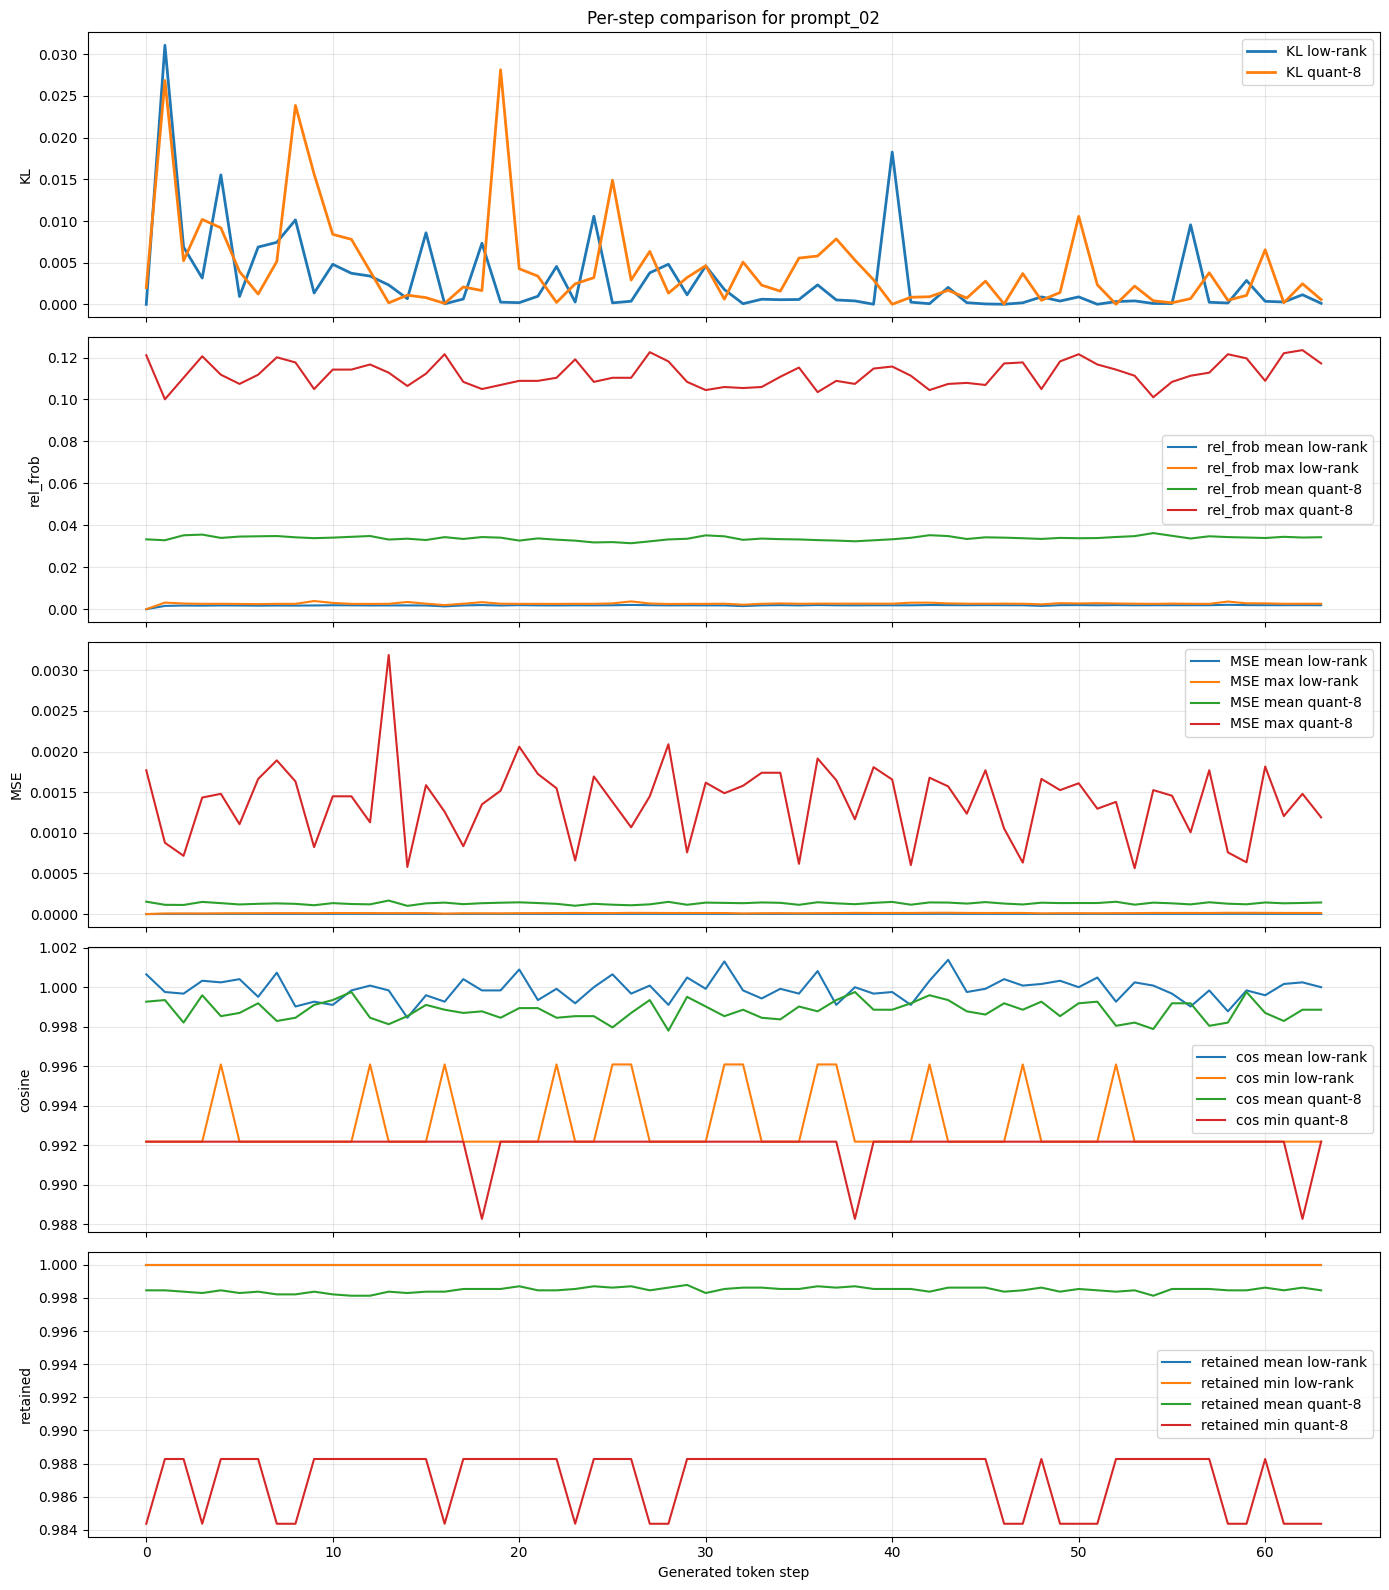

In [38]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

axes[0].plot(steps_svd, kl_svd.numpy(), label="KL low-rank", linewidth=2)
axes[0].plot(steps_q, kl_q.numpy(), label="KL quant-8", linewidth=2)
axes[0].set_ylabel("KL")
axes[0].set_title(f"Per-step comparison for {PROMPT_ID}")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(steps_svd, rf_mean_svd.numpy(), label="rel_frob mean low-rank")
axes[1].plot(steps_svd, rf_max_svd.numpy(), label="rel_frob max low-rank")
axes[1].plot(steps_q, rf_mean_q.numpy(), label="rel_frob mean quant-8")
axes[1].plot(steps_q, rf_max_q.numpy(), label="rel_frob max quant-8")
axes[1].set_ylabel("rel_frob")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(steps_svd, mse_mean_svd.numpy(), label="MSE mean low-rank")
axes[2].plot(steps_svd, mse_max_svd.numpy(), label="MSE max low-rank")
axes[2].plot(steps_q, mse_mean_q.numpy(), label="MSE mean quant-8")
axes[2].plot(steps_q, mse_max_q.numpy(), label="MSE max quant-8")
axes[2].set_ylabel("MSE")
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(steps_svd, cos_mean_svd.numpy(), label="cos mean low-rank")
axes[3].plot(steps_svd, cos_min_svd.numpy(), label="cos min low-rank")
axes[3].plot(steps_q, cos_mean_q.numpy(), label="cos mean quant-8")
axes[3].plot(steps_q, cos_min_q.numpy(), label="cos min quant-8")
axes[3].set_ylabel("cosine")
axes[3].legend()
axes[3].grid(alpha=0.3)

axes[4].plot(steps_svd, re_mean_svd.numpy(), label="retained mean low-rank")
axes[4].plot(steps_svd, re_min_svd.numpy(), label="retained min low-rank")
axes[4].plot(steps_q, re_mean_q.numpy(), label="retained mean quant-8")
axes[4].plot(steps_q, re_min_q.numpy(), label="retained min quant-8")
axes[4].set_ylabel("retained")
axes[4].set_xlabel("Generated token step")
axes[4].legend()
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()


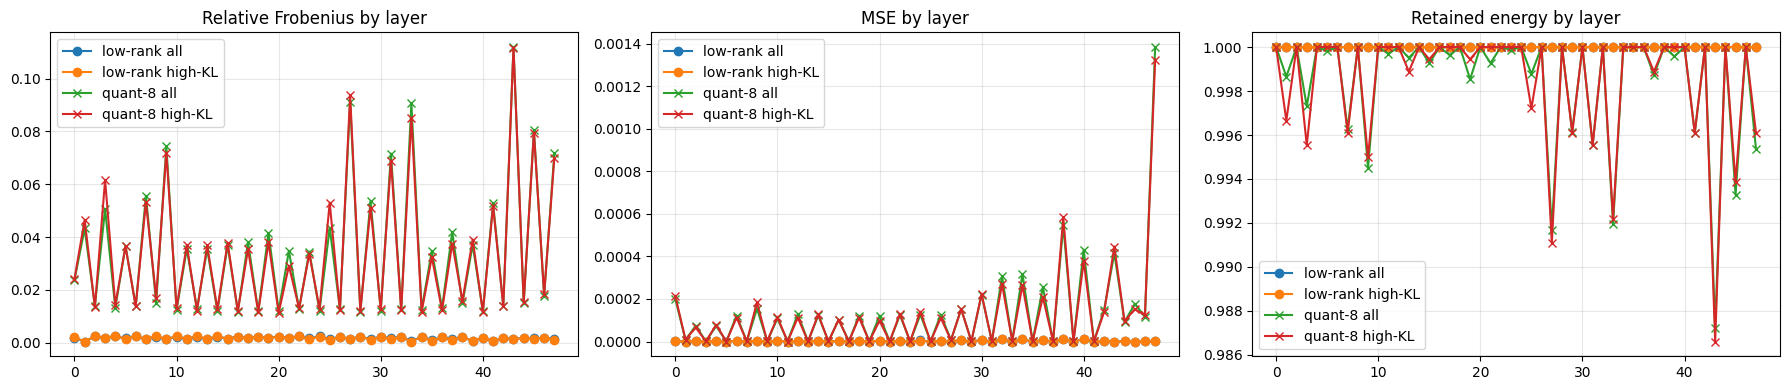

In [39]:
# 2. Layer profiles for one prompt: all steps vs high-KL steps
layers = np.arange(rf_svd.shape[1])

rf_base_svd = rf_svd.mean(dim=0)
rf_high_svd = rf_svd[high_mask_svd].mean(dim=0)
mse_base_svd = mse_svd.mean(dim=0)
mse_high_svd = mse_svd[high_mask_svd].mean(dim=0)
re_base_svd = re_svd.mean(dim=0)
re_high_svd = re_svd[high_mask_svd].mean(dim=0)

rf_base_q = rf_q.mean(dim=0)
rf_high_q = rf_q[high_mask_q].mean(dim=0)
mse_base_q = mse_q.mean(dim=0)
mse_high_q = mse_q[high_mask_q].mean(dim=0)
re_base_q = re_q.mean(dim=0)
re_high_q = re_q[high_mask_q].mean(dim=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(layers, rf_base_svd.numpy(), marker="o", label="low-rank all")
axes[0].plot(layers, rf_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[0].plot(layers, rf_base_q.numpy(), marker="x", label="quant-8 all")
axes[0].plot(layers, rf_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[0].set_title("Relative Frobenius by layer")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(layers, mse_base_svd.numpy(), marker="o", label="low-rank all")
axes[1].plot(layers, mse_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[1].plot(layers, mse_base_q.numpy(), marker="x", label="quant-8 all")
axes[1].plot(layers, mse_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[1].set_title("MSE by layer")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(layers, re_base_svd.numpy(), marker="o", label="low-rank all")
axes[2].plot(layers, re_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[2].plot(layers, re_base_q.numpy(), marker="x", label="quant-8 all")
axes[2].plot(layers, re_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[2].set_title("Retained energy by layer")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [40]:
# 3. Prompt-level KL summaries, mirroring the original notebook
def get_kl_tensors(records):
    return [r["kl"].float().cpu().numpy() for r in records if r["kl"] is not None]

kl_tensors_svd = get_kl_tensors(records_svd)
kl_tensors_q = get_kl_tensors(records_q)

def trimmed_mean(arr, percentiles=(10, 90)):
    bottom, top = np.percentile(arr, percentiles)
    trimmed = arr[(arr >= bottom) & (arr <= top)]
    return float(np.mean(trimmed))

def spike_rate(arr, spike_threshold=2.0):
    return float(np.mean(arr > spike_threshold))

kl_median_svd = [np.median(t) for t in kl_tensors_svd]
kl_median_q = [np.median(t) for t in kl_tensors_q]

kl_trimmed_mean_svd = [trimmed_mean(t) for t in kl_tensors_svd]
kl_trimmed_mean_q = [trimmed_mean(t) for t in kl_tensors_q]

kl_p99_svd = [np.percentile(t, 99) for t in kl_tensors_svd]
kl_p99_q = [np.percentile(t, 99) for t in kl_tensors_q]

spike_rates_svd = [spike_rate(t) for t in kl_tensors_svd]
spike_rates_q = [spike_rate(t) for t in kl_tensors_q]

print("Average spike rate low-rank:", np.mean(spike_rates_svd))
print("Average spike rate quant-8:", np.mean(spike_rates_q))


Average spike rate low-rank: 0.0
Average spike rate quant-8: 0.0


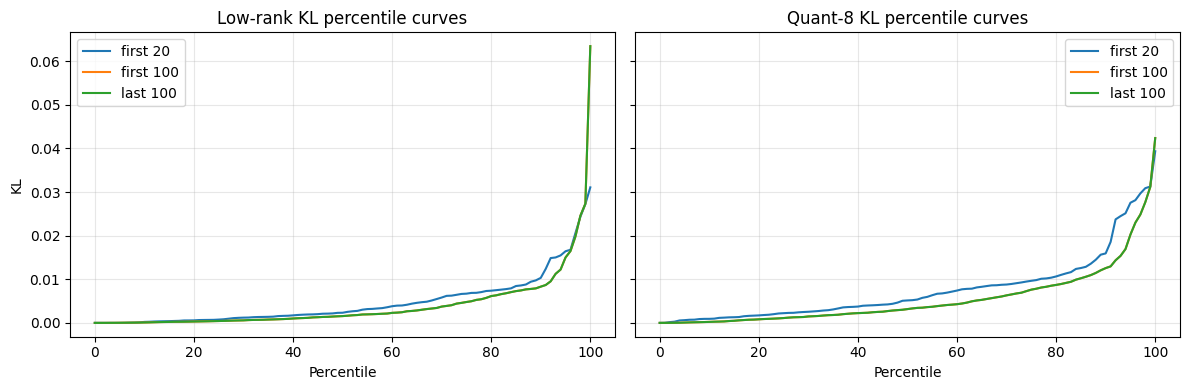

In [41]:
# 4. Percentile curves for early vs late generated tokens
def flatten_numeric(values):
    flat = []
    for v in values:
        flat.extend(np.asarray(v).ravel().tolist())
    return np.asarray(flat, dtype=float)

def crop_prefix(tensors, n):
    return [t[: min(n, len(t))] for t in tensors]

def crop_suffix(tensors, n):
    return [t[-min(n, len(t)):] for t in tensors]

percentiles = np.linspace(0, 100, 101)

svd_first20 = flatten_numeric(crop_prefix(kl_tensors_svd, 20))
svd_first100 = flatten_numeric(crop_prefix(kl_tensors_svd, 100))
svd_last100 = flatten_numeric(crop_suffix(kl_tensors_svd, 100))

q_first20 = flatten_numeric(crop_prefix(kl_tensors_q, 20))
q_first100 = flatten_numeric(crop_prefix(kl_tensors_q, 100))
q_last100 = flatten_numeric(crop_suffix(kl_tensors_q, 100))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(percentiles, np.percentile(svd_first20, percentiles), label="first 20")
axes[0].plot(percentiles, np.percentile(svd_first100, percentiles), label="first 100")
axes[0].plot(percentiles, np.percentile(svd_last100, percentiles), label="last 100")
axes[0].set_title("Low-rank KL percentile curves")
axes[0].set_xlabel("Percentile")
axes[0].set_ylabel("KL")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(percentiles, np.percentile(q_first20, percentiles), label="first 20")
axes[1].plot(percentiles, np.percentile(q_first100, percentiles), label="first 100")
axes[1].plot(percentiles, np.percentile(q_last100, percentiles), label="last 100")
axes[1].set_title("Quant-8 KL percentile curves")
axes[1].set_xlabel("Percentile")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [42]:
# 5. Direct paired comparison across prompts
comparison = pd.DataFrame({
    "prompt_id": common_prompt_ids,
    "kl_mean_low_rank": [
        float(records_svd_by_id[p]["kl"].float().mean().item()) for p in common_prompt_ids
    ],
    "kl_mean_quant_8": [
        float(records_q_by_id[p]["kl"].float().mean().item()) for p in common_prompt_ids
    ],
    "mse_mean_low_rank": [
        float(records_svd_by_id[p]["mse"].float().mean().item()) for p in common_prompt_ids
    ],
    "mse_mean_quant_8": [
        float(records_q_by_id[p]["mse"].float().mean().item()) for p in common_prompt_ids
    ],
    "rel_frob_mean_low_rank": [
        float(records_svd_by_id[p]["rel_frob"].float().mean().item()) for p in common_prompt_ids
    ],
    "rel_frob_mean_quant_8": [
        float(records_q_by_id[p]["rel_frob"].float().mean().item()) for p in common_prompt_ids
    ],
    "cos_mean_low_rank": [
        float(records_svd_by_id[p]["cosine_similarity"].float().mean().item()) for p in common_prompt_ids
    ],
    "cos_mean_quant_8": [
        float(records_q_by_id[p]["cosine_similarity"].float().mean().item()) for p in common_prompt_ids
    ],
    "retained_mean_low_rank": [
        float(records_svd_by_id[p]["retained_energy"].float().mean().item()) for p in common_prompt_ids
    ],
    "retained_mean_quant_8": [
        float(records_q_by_id[p]["retained_energy"].float().mean().item()) for p in common_prompt_ids
    ],
})

comparison["kl_mean_diff"] = comparison["kl_mean_quant_8"] - comparison["kl_mean_low_rank"]
comparison["mse_mean_diff"] = comparison["mse_mean_quant_8"] - comparison["mse_mean_low_rank"]
comparison["rel_frob_mean_diff"] = comparison["rel_frob_mean_quant_8"] - comparison["rel_frob_mean_low_rank"]
comparison["cos_mean_diff"] = comparison["cos_mean_quant_8"] - comparison["cos_mean_low_rank"]
comparison["retained_mean_diff"] = comparison["retained_mean_quant_8"] - comparison["retained_mean_low_rank"]

comparison


,prompt_id,kl_mean_low_rank,kl_mean_quant_8,mse_mean_low_rank,mse_mean_quant_8,rel_frob_mean_low_rank,rel_frob_mean_quant_8,cos_mean_low_rank,cos_mean_quant_8,retained_mean_low_rank,retained_mean_quant_8,kl_mean_diff,mse_mean_diff,rel_frob_mean_diff,cos_mean_diff,retained_mean_diff
0,prompt_01,0.005122,0.007501,0.000003,0.000139,0.001865,0.032814,1.000056,0.998835,1.0,0.998554,0.002379,0.000136,0.030949,-0.001221,-0.001446
1,prompt_02,0.003010,0.004466,0.000003,0.000131,0.001823,0.033873,0.999896,0.998820,1.0,0.998474,0.001456,0.000129,0.032050,-0.001076,-0.001526
2,prompt_03,0.003356,0.007231,0.000003,0.000140,0.001785,0.034680,0.999987,0.998880,1.0,0.998430,0.003875,0.000138,0.032895,-0.001108,-0.001570
3,prompt_04,0.005174,0.005089,0.000002,0.000142,0.001776,0.034526,0.999896,0.998793,1.0,0.998366,-0.000085,0.000140,0.032749,-0.001102,-0.001634
4,prompt_05,0.001984,0.003809,0.000003,0.000139,0.001934,0.033217,0.999982,0.998965,1.0,0.998545,0.001825,0.000136,0.031283,-0.001017,-0.001455
5,prompt_06,0.004557,0.004031,0.000002,0.000136,0.001708,0.032615,1.000043,0.999050,1.0,0.998597,-0.000526,0.000133,0.030907,-0.000993,-0.001403
6,prompt_07,0.003836,0.004652,0.000003,0.000129,0.001825,0.033052,0.999827,0.998904,1.0,0.998571,0.000815,0.000126,0.031227,-0.000923,-0.001429
7,prompt_08,0.002351,0.007048,0.000003,0.000126,0.001908,0.034788,0.999938,0.998924,1.0,0.998338,0.004697,0.000123,0.032880,-0.001013,-0.001662
8,prompt_09,0.003702,0.007554,0.000003,0.000137,0.001740,0.033876,0.999963,0.998807,1.0,0.998360,0.003852,0.000135,0.032136,-0.001156,-0.001640
9,prompt_10,0.003621,0.003253,0.000003,0.000126,0.001839,0.033620,0.999910,0.998870,1.0,0.998468,-0.000368,0.000123,0.031780,-0.001040,-0.001532


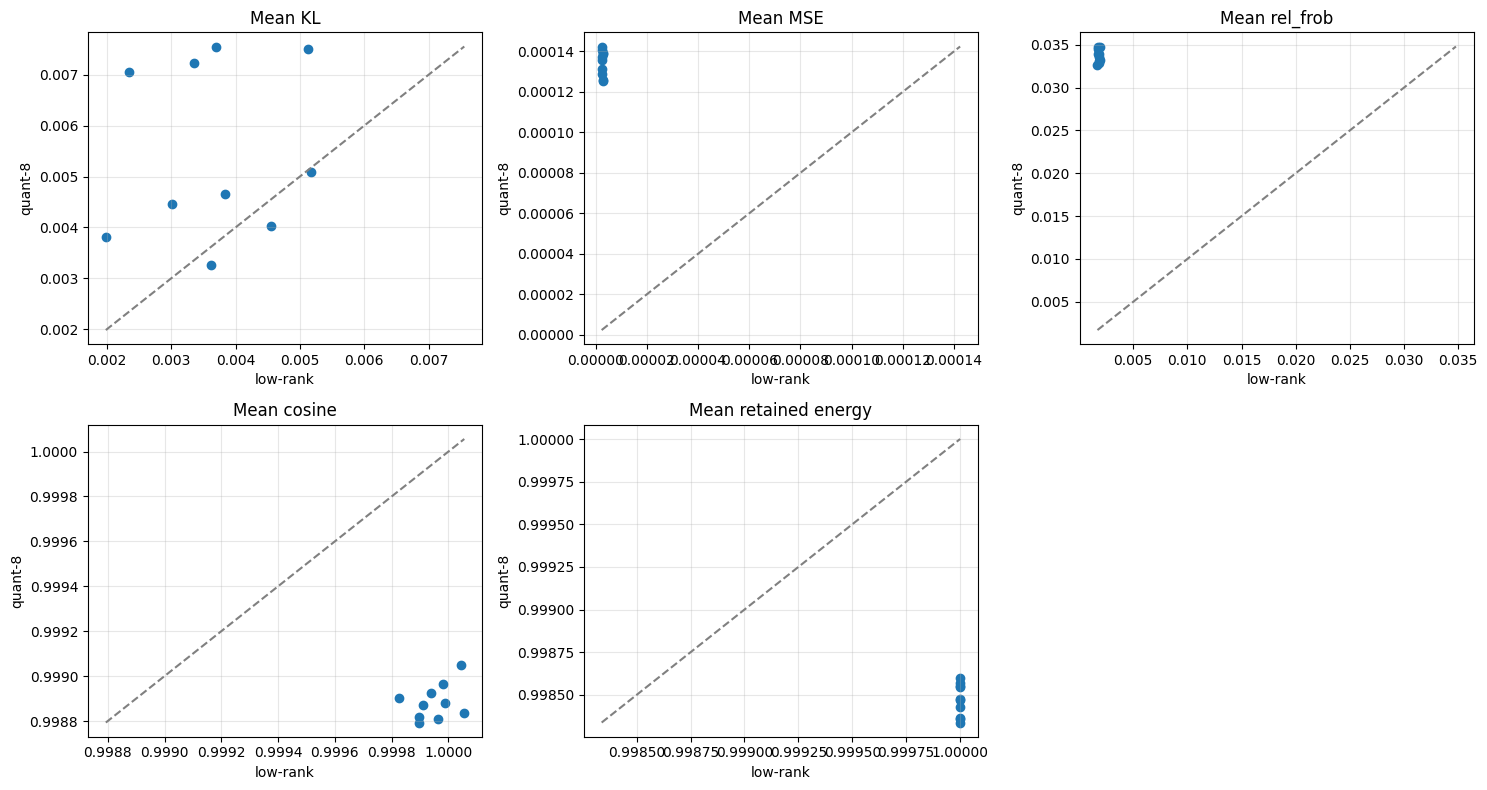

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plots = [
    ("kl_mean_low_rank", "kl_mean_quant_8", "Mean KL"),
    ("mse_mean_low_rank", "mse_mean_quant_8", "Mean MSE"),
    ("rel_frob_mean_low_rank", "rel_frob_mean_quant_8", "Mean rel_frob"),
    ("cos_mean_low_rank", "cos_mean_quant_8", "Mean cosine"),
    ("retained_mean_low_rank", "retained_mean_quant_8", "Mean retained energy"),
]

for ax, (xcol, ycol, title) in zip(axes.ravel(), plots):
    ax.scatter(comparison[xcol], comparison[ycol])
    lo = min(comparison[xcol].min(), comparison[ycol].min())
    hi = max(comparison[xcol].max(), comparison[ycol].max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray")
    ax.set_xlabel("low-rank")
    ax.set_ylabel("quant-8")
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()


In [44]:
# 6. Meta.json inspection: state names and timing
meta_rows = []
for prompt_id in common_prompt_ids:
    meta_svd = records_svd_by_id[prompt_id]["meta"]
    meta_q = records_q_by_id[prompt_id]["meta"]
    meta_rows.append({
        "prompt_id": prompt_id,
        "prefill_seconds_low_rank": meta_svd.get("prefill_seconds"),
        "prefill_seconds_quant_8": meta_q.get("prefill_seconds"),
        "average_transform_seconds_low_rank": meta_svd.get("average_transform_seconds"),
        "average_transform_seconds_quant_8": meta_q.get("average_transform_seconds"),
        "num_state_tensors_low_rank": meta_svd.get("num_state_tensors"),
        "num_state_tensors_quant_8": meta_q.get("num_state_tensors"),
    })

meta_df = pd.DataFrame(meta_rows)
meta_df


,prompt_id,prefill_seconds_low_rank,prefill_seconds_quant_8,average_transform_seconds_low_rank,average_transform_seconds_quant_8,num_state_tensors_low_rank,num_state_tensors_quant_8
0,prompt_01,0.627469,0.336079,0.094554,0.029850,48,48
1,prompt_02,0.013958,0.013787,0.092526,0.020092,48,48
2,prompt_03,0.014923,0.014769,0.096838,0.024651,48,48
3,prompt_04,0.020004,0.021949,0.096804,0.033386,48,48
4,prompt_05,0.018840,0.019494,0.078126,0.031728,48,48
5,prompt_06,0.017661,0.017721,0.089917,0.043703,48,48
6,prompt_07,0.018387,0.017877,0.091960,0.040928,48,48
7,prompt_08,0.016083,0.015356,0.078456,0.037362,48,48
8,prompt_09,0.017152,0.016295,0.072915,0.046251,48,48
9,prompt_10,0.017787,0.017841,0.087379,0.040748,48,48


In [46]:
# Inspect state names from one prompt
sample_meta = records_svd_by_id[common_prompt_ids[0]]["meta"]
state_names = sample_meta.get("state_names", [])
state_names[:10], len(state_names)


([], 0)

In [47]:
# Response text side-by-side
prompt_id = common_prompt_ids[0]
print("LOW-RANK RESPONSE\n")
print(records_svd_by_id[prompt_id]["response_text"][:1000])

print("\n" + "=" * 80 + "\n")

print("QUANT-8 RESPONSE\n")
print(records_q_by_id[prompt_id]["response_text"][:1000])


LOW-RANK RESPONSE

PROMPT:
Hi there! Who are you?

RESPONSE:
I'm Kirsten, a newbie to the world of blogging. I'm a huge fan of the blogosphere and have been blogging for over a year now. I'm a proud member of the Blogger Network and I'm also a member of the Blogger Club. I'm a huge fan of the blog



QUANT-8 RESPONSE

PROMPT:
Hi there! Who are you?

RESPONSE:
I am a writer, blogger, and freelance writer. I am a fan of all things vintage, and have been for years. I am also a big fan of all things vintage, and have been for years. I am a big fan of all things vintage, and have been for years. I am a

